<a href="https://colab.research.google.com/github/sitahlango-maker/Financial_Inclusion/blob/main/cleanfinancialinclusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Installing Basic Liberaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Imports the pandas library for data handling and analysis.
import pandas as pd

In [ ]:
# Loads the Kenya survey data file from the public GitHub repository.
df_ken = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Kenya.csv')

# Loads the Tanzania survey data file from the public GitHub repository.
df_tza = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Tanzania.csv')

# Loads the Uganda survey data file from the public GitHub repository.
df_uga = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Uganda.csv')

In [ ]:
# Prints the number of rows and columns for each country’s survey file to confirm successful loading.
print("Kenya shape:", df_ken.shape)
print("Tanzania shape:", df_tza.shape)
print("Uganda shape:", df_uga.shape)

# Shows the first 15 column names of the Kenya file to check the structure.
print("\nKenya columns:", df_ken.columns.tolist()[:15], "...")

Kenya shape: (1000, 183)
Tanzania shape: (1000, 183)
Uganda shape: (1000, 183)

Kenya columns: ['year', 'economy', 'economycode', 'regionwb', 'pop_adult', 'wpid_random', 'wgt', 'female', 'age', 'educ', 'inc_q', 'emp_in', 'urbanicity', 'account_fin', 'account_mob'] ...


**Cleaning** **initial** **Findex** **Dataset**

In [ ]:
# Defines a function to clean one Findex survey file.
def clean_findex(df, country_code, country_name):

    # Creates a copy of the input DataFrame to avoid changing the original.
    df = df.copy()

    # Adds the full country name as a new column.
    df['country'] = country_name

    # Adds the three-letter country code as a new column.
    df['country_code'] = country_code

    # Checks if the survey weight column exists and converts it to numeric values.
    if 'wgt' in df.columns:
        df['wgt'] = pd.to_numeric(df['wgt'], errors='coerce')

    # Defines the main outcome columns that measure mobile money and digital use.
    target_cols = ['account_mob', 'dig_account', 'anydigpayment']

    # Loops through each outcome column and converts it to numeric values.
    for col in target_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Lists the most important columns to keep in the cleaned file.
    keep = ['country', 'country_code', 'wgt', 'female', 'age', 'educ', 'inc_q',
            'urbanicity', 'account_mob', 'dig_account', 'anydigpayment', 'internet_use']

    # Removes any listed columns that do not exist in the DataFrame.
    keep = [c for c in keep if c in df.columns]

    # Keeps only the selected columns and discards the rest.
    df = df[keep]

    # Returns the cleaned DataFrame.
    return df

# Loads the Kenya survey file directly from the public GitHub repository.
df_ken = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Kenya.csv')

# Loads the Tanzania survey file directly from the public GitHub repository.
df_tza = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Tanzania.csv')

# Loads the Uganda survey file directly from the public GitHub repository.
df_uga = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Uganda.csv')

# Cleans the Kenya data using the function defined earlier.
df_ken_clean = clean_findex(df_ken, 'KEN', 'Kenya')

# Cleans the Tanzania data using the function defined earlier.
df_tza_clean = clean_findex(df_tza, 'TZA', 'Tanzania')

# Cleans the Uganda data using the function defined earlier.
df_uga_clean = clean_findex(df_uga, 'UGA', 'Uganda')

# Combines the three cleaned files into one table (df_micro).
df_micro = pd.concat([df_ken_clean, df_tza_clean, df_uga_clean], ignore_index=True)

# Prints a confirmation message with the shape of the combined table.
print("df_micro defined. Shape:", df_micro.shape)

df_micro defined. Shape: (3000, 12)


In [ ]:
# Cleans Kenya survey data using the cleaning function.
df_ken_clean = clean_findex(df_ken, 'KEN', 'Kenya')

# Cleans Tanzania survey data using the cleaning function.
df_tza_clean = clean_findex(df_tza, 'TZA', 'Tanzania')

# Cleans Uganda survey data using the cleaning function.
df_uga_clean = clean_findex(df_uga, 'UGA', 'Uganda')

# Combines three cleaned files into one single table.
df_micro = pd.concat([df_ken_clean, df_tza_clean, df_uga_clean], ignore_index=True)

# Prints total rows and columns of combined table.
print("Combined microdata shape:", df_micro.shape)

# Shows how many rows belong to each country.
print(df_micro['country'].value_counts())

# Prints percentage of missing values in each column (top 12).
print("\nMissing values (%):\n", df_micro.isna().mean().sort_values(ascending=False).head(12))

Combined microdata shape: (3000, 12)
country
Kenya       1000
Tanzania    1000
Uganda      1000
Name: count, dtype: int64

Missing values (%):
 educ             0.001
country          0.000
wgt              0.000
country_code     0.000
female           0.000
age              0.000
inc_q            0.000
urbanicity       0.000
account_mob      0.000
dig_account      0.000
anydigpayment    0.000
internet_use     0.000
dtype: float64


**Loading the country level dataset**

In [ ]:
# Loads prevalence index file .
df_preval = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/refs/heads/main/Colab%20Notebooks/FinancialInclution/Mobile%20Money%20Prevalent%20Index-2020-23-Public(MMPI%202020-23).csv')

# Keeps only needed columns and removes rows without valid code.
df_preval = df_preval[['Country', 'ISO3', 'Mobile Money Prevalence (2023)']].dropna(subset=['ISO3'])

# Changes column names to be short and clear.
df_preval.columns = ['country_name', 'country_code', 'mmpi_2023']

# Keeps only Kenya, Tanzania, and Uganda rows.
df_preval = df_preval[df_preval['country_code'].isin(['KEN', 'TZA', 'UGA'])]

In [ ]:
# Loads regulatory index file
df_reg = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Mobile_Money_Regulatory_Index_Database_2025_v2(Data).csv')

# Keeps only rows from year 2025 (latest data).
df_reg = df_reg[df_reg['Year'] == 2025]

# Keeps only selected columns that are most relevant.
df_reg = df_reg[['Country', 'Index', 'Consumer Protection', 'KYC Proportionality',
                 'Entry-level transaction limits', 'Maximum transaction limits', 'Agent Eligibility']]

# Changes column names to be short and clear.
df_reg.columns = ['country_name', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop',
                  'reg_entry_lim', 'reg_max_lim', 'reg_agent_el']

# Adds short country code using country name.
df_reg['country_code'] = df_reg['country_name'].map({'Kenya': 'KEN', 'Tanzania': 'TZA', 'Uganda': 'UGA'})

# Keeps only Kenya, Tanzania, and Uganda rows.
df_reg = df_reg[df_reg['country_code'].isin(['KEN', 'TZA', 'UGA'])]

In [ ]:
# Loads deployment tracker file
df_deploy = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/refs/heads/main/Colab%20Notebooks/FinancialInclution/Mobile%20Money%20Deployment.csv')

# Keeps only rows for Kenya, Tanzania, and Uganda.
df_deploy = df_deploy[df_deploy['Country ISO Code'].isin(['KEN', 'TZA', 'UGA'])]

# Counts number of mobile money providers per country.
df_providers = df_deploy.groupby('Country ISO Code').size().reset_index(name='num_providers')

# Changes country code column name to match others.
df_providers = df_providers.rename(columns={'Country ISO Code': 'country_code'})

# Changes launch year to numbers (ignores errors).
df_deploy['launch_year'] = pd.to_numeric(df_deploy['Launch Year'], errors='coerce')

# Finds earliest launch year per country.
df_oldest = df_deploy.groupby('Country ISO Code')['launch_year'].min().reset_index(name='earliest_launch_year')

# Changes country code column name to match others.
df_oldest = df_oldest.rename(columns={'Country ISO Code': 'country_code'})

**Building Country Facts Table**

In [ ]:
# Starts country facts table with prevalence category.
df_country_facts = df_preval[['country_code', 'mmpi_2023']].copy()

# Adds regulatory scores using left join.
df_country_facts = df_country_facts.merge(
    df_reg[['country_code', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop',
            'reg_entry_lim', 'reg_max_lim', 'reg_agent_el']],
    on='country_code',
    how='left'
)

# Combines provider count and earliest launch year.
df_deploy_info = df_providers.merge(df_oldest, on='country_code', how='left')

# Adds provider information to country facts table.
df_country_facts = df_country_facts.merge(df_deploy_info, on='country_code', how='left')

# Prints the final country facts table.
print(df_country_facts)

  country_code  mmpi_2023  reg_index  reg_cons_prot  reg_kyc_prop  \
0          KEN  Very high      88.00         100.00             0   
1          TZA  Very high      87.16          83.33           100   
2          UGA  Very high      88.33         100.00           100   

   reg_entry_lim  reg_max_lim  reg_agent_el  num_providers  \
0            100          100           100              4   
1            100          100           100              6   
2            100          100           100              7   

   earliest_launch_year  
0                  2007  
1                  2008  
2                  2009  


**Selecting Survey Columns and Final Combination**

In [ ]:
# Lists most useful columns from survey data.
keep_survey = [
    'country_code', 'female', 'age', 'educ', 'inc_q', 'urbanicity',
    'account_mob', 'dig_account', 'anydigpayment', 'internet_use', 'wgt'
]

# Keeps only selected columns from combined survey data.
df_survey_clean = df_micro[keep_survey].copy()

# Joins survey data with country facts using country code.
df_final = df_survey_clean.merge(df_country_facts, on='country_code', how='left')

# Prints final table size to confirm.
print("Final combined dataset shape:", df_final.shape)

# Prints first few rows of final table.
print("First few rows:\n", df_final.head())

# Prints percentage of missing values in each column.
print("\nMissing values (%):\n", df_final.isna().mean().sort_values(ascending=False).head(10))

Final combined dataset shape: (3000, 20)
First few rows:
   country_code  female  age  educ  inc_q  urbanicity  account_mob  \
0          KEN       1   25   2.0      1           1            1   
1          KEN       1   26   2.0      4           1            1   
2          KEN       1   21   2.0      3           1            1   
3          KEN       1   25   2.0      5           1            1   
4          KEN       2   31   3.0      5           2            1   

   dig_account  anydigpayment  internet_use       wgt  mmpi_2023  reg_index  \
0            1              1             1  0.723252  Very high       88.0   
1            1              1             1  0.331405  Very high       88.0   
2            1              1             1  1.071302  Very high       88.0   
3            1              1             1  0.677005  Very high       88.0   
4            1              1             1  0.457662  Very high       88.0   

   reg_cons_prot  reg_kyc_prop  reg_entry_lim  reg_m

**Saving the Final Dataset as CSV**

In [ ]:
# Save the dataset as CSV in Colab's temporary storage
df_final.to_csv('FinalCombine.csv', index=False)

# Install git if not already available (usually pre-installed in Colab)
!apt-get update -qq && apt-get install -y git

# Configure git with your details (replace with your own email and username)
!git config --global user.email "your-email@example.com"
!git config --global user.name "Your GitHub Username"

# Clone your repository (replace with your actual repo URL)
!git clone https://github.com/sitahlango-maker/Financial_Inclusion.git
%cd Financial_Inclusion

# Move the CSV file to the desired folder inside the repo
!mkdir -p "Colab Notebooks/FinancialInclution"
!mv ../FinalCombine.csv "Colab Notebooks/FinancialInclution/FinalCombine.csv"

# Add, commit, and push the file to GitHub
!git add "Colab Notebooks/FinancialInclution/FinalCombine.csv"
!git commit -m "Add FinalCombine.csv - combined Findex and country-level dataset"
!git push origin main

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 15 not upgraded.
Cloning into 'Financial_Inclusion'...
remote: Enumerating objects: 366, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 366 (delta 67), reused 31 (delta 31), pack-reused 282 (from 3)
Receiving objects: 100% (366/366), 9.78 MiB | 17.26 MiB/s, done.
Resolving deltas: 100% (169/169), done.
/content/Financial_Inclusion
[main 9ab0220] Add FinalCombine.csv - combined Findex and country-level dataset
 1 file changed, 0 insertions(+), 0 deletions(-)
 rewrite Colab Notebooks/FinancialInclution/FinalCombine.csv (97%)
fatal: could

In [ ]:
# Load the Mobile Money Deployment Tracker
df_preval = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/refs/heads/main/Colab%20Notebooks/FinancialInclution/Mobile%20Money%20Prevalent%20Index-2020-23-Public(MMPI%202020-23).csv',
 )

# Rename column for merging
df_preval = df_preval[['Country', 'ISO3', 'Mobile Money Prevalence (2023)']]

#--Remove rows without valid country code
df_preval = df_preval.dropna(subset=['ISO3'])

#Select the columns to be used:
df_preval = df_preval[['Country', 'ISO3', 'Mobile Money Prevalence (2023)']]

#Make the column names short and clear
df_preval.columns = ['country_name', 'country_code', 'mmpi_2023']


#Keep only three countries (Kenya, Uganda and Tanzania)
df_preval = df_preval[df_preval['country_code'].isin(['KEN', 'TZA', 'UGA'])]

df_preval.columns.tolist()

['country_name', 'country_code', 'mmpi_2023']

**Combining the four latter GSMA datasets With the Original Findex Dataset**

In [ ]:
df_country_facts = df_preval[['country_code', 'mmpi_2023']].copy()
df_country_facts = df_country_facts.merge(df_reg[['country_code', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop',
                                                  'reg_entry_lim', 'reg_max_lim', 'reg_agent_el']],
                                          on='country_code', how='left')
df_deploy_info = df_providers.merge(df_oldest, on='country_code', how='left')
df_country_facts = df_country_facts.merge(df_deploy_info, on='country_code', how='left')

In [ ]:
# Preparing microdata (the three Findex survey files already combined in df_micro)
# Adding country_code (just in case it's not updated properly)
df_micro['country_code'] = df_micro['country'].map({
    'Kenya': 'KEN',
    'Tanzania': 'TZA',
    'Uganda': 'UGA'
})

In [ ]:
# Keep only the most useful survey columns
keep_survey = [
    'country_code', 'female', 'age', 'educ', 'inc_q', 'urbanicity',
    'account_mob', 'dig_account', 'anydigpayment', 'internet_use', 'wgt'
]
df_survey_clean = df_micro[keep_survey].copy()

In [ ]:
# Building one small country facts table from the other five sources
# Starting with prevalence dataset as base
df_country_facts = df_preval[['country_code', 'mmpi_2023']].copy()

In [ ]:
# Adding regulatory scores
df_country_facts = df_country_facts.merge(
    df_reg[['country_code', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop',
            'reg_entry_lim', 'reg_max_lim', 'reg_agent_el']],
    on='country_code',
    how='left'
)

In [ ]:
# Adding the number of providers and earliest launch year
df_providers = df_deploy.groupby('Country ISO Code').size().reset_index(name='num_providers')
df_earliest = df_deploy.groupby('Country ISO Code')['launch_year'].min().reset_index(name='earliest_launch')
df_providers = df_providers.rename(columns={'Country ISO Code': 'country_code'})
df_earliest  = df_earliest.rename(columns={'Country ISO Code': 'country_code'})

df_deploy_info = df_providers.merge(df_earliest, on='country_code', how='left')
df_country_facts = df_country_facts.merge(df_deploy_info, on='country_code', how='left')

In [ ]:
# Joining the country facts to every row of the survey data
df_final = df_survey_clean.merge(
    df_country_facts,
    on='country_code',
    how='left'
)

In [ ]:
# Checking the result
print("Final combined dataset shape:", df_final.shape)
print("First few rows:\n", df_final.head())
print("\nMissing values (%):\n", df_final.isna().mean().sort_values(ascending=False).head(10))

Final combined dataset shape: (3000, 20)
First few rows:
   country_code  female  age  educ  inc_q  urbanicity  account_mob  \
0          KEN       1   25   2.0      1           1            1   
1          KEN       1   26   2.0      4           1            1   
2          KEN       1   21   2.0      3           1            1   
3          KEN       1   25   2.0      5           1            1   
4          KEN       2   31   3.0      5           2            1   

   dig_account  anydigpayment  internet_use       wgt  mmpi_2023  reg_index  \
0            1              1             1  0.723252  Very high       88.0   
1            1              1             1  0.331405  Very high       88.0   
2            1              1             1  1.071302  Very high       88.0   
3            1              1             1  0.677005  Very high       88.0   
4            1              1             1  0.457662  Very high       88.0   

   reg_cons_prot  reg_kyc_prop  reg_entry_lim  reg_m

In [ ]:
# Saving the final file
df_final.to_csv(
    'https://github.com/sitahlango-maker/Financial_Inclusion/tree/main/Colab%20Notebooks/FinancialInclution',
    index=False
)

In [ ]:
# Import libraries needed for data preparation and modelling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Set display options for better readability
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

**Saving the Cleaned Raw Dataset**

In [ ]:
df_final.to_csv('cleaned_multiple_country_dataset.csv',index=False)

In [ ]:
# Display basic information about the loaded data
print("Dataset shape:", df_final.shape)
print("\nFirst few rows:")
print(df_final.head())
print("\nColumn names:")
print(df_final.columns.tolist())
print("\nMissing values (%):")
print(df_final.isna().mean().sort_values(ascending=False).head(10))


Dataset shape: (3000, 20)

First few rows:
  country_code  female  age   educ  inc_q  urbanicity  account_mob  \
0          KEN       1   25 2.0000      1           1            1   
1          KEN       1   26 2.0000      4           1            1   
2          KEN       1   21 2.0000      3           1            1   
3          KEN       1   25 2.0000      5           1            1   
4          KEN       2   31 3.0000      5           2            1   

   dig_account  anydigpayment  internet_use    wgt  mmpi_2023  reg_index  \
0            1              1             1 0.7233  Very high    88.0000   
1            1              1             1 0.3314  Very high    88.0000   
2            1              1             1 1.0713  Very high    88.0000   
3            1              1             1 0.6770  Very high    88.0000   
4            1              1             1 0.4577  Very high    88.0000   

   reg_cons_prot  reg_kyc_prop  reg_entry_lim  reg_max_lim  reg_agent_el  \
0  

In [ ]:
# Imports pandas for loading and managing data tables.
import pandas as pd

# Imports numpy for numerical calculations and array handling.
import numpy as np

# Imports matplotlib and seaborn for creating plots and visual checks.
import matplotlib.pyplot as plt
import seaborn as sns

# Imports tools from scikit-learn for splitting data and building models.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [ ]:

# Prints the shape (rows and columns) of the loaded data to confirm it is correct.
print("Dataset shape:", df_final.shape)


Dataset shape: (3000, 20)


In [ ]:

# Prints all column names to see what features are available.
print("\nColumn names:")
print(df_final.columns.tolist())


Column names:
['country_code', 'female', 'age', 'educ', 'inc_q', 'urbanicity', 'account_mob', 'dig_account', 'anydigpayment', 'internet_use', 'wgt', 'mmpi_2023', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el', 'num_providers', 'earliest_launch']


In [ ]:
# Prints the percentage of missing values in each column (sorted highest to lowest).
print("\nMissing values (%):")
print(df_final.isna().mean().sort_values(ascending=False).head(15))


Missing values (%):
educ            0.0010
country_code    0.0000
female          0.0000
age             0.0000
inc_q           0.0000
urbanicity      0.0000
account_mob     0.0000
dig_account     0.0000
anydigpayment   0.0000
internet_use    0.0000
wgt             0.0000
mmpi_2023       0.0000
reg_index       0.0000
reg_cons_prot   0.0000
reg_kyc_prop    0.0000
dtype: float64


In [ ]:
# Prints the data types of each column to check they are correct.
print("\nData types:")
print(df_final.dtypes)


Data types:
country_code        object
female               int64
age                  int64
educ               float64
inc_q                int64
urbanicity           int64
account_mob          int64
dig_account          int64
anydigpayment        int64
internet_use         int64
wgt                float64
mmpi_2023           object
reg_index          float64
reg_cons_prot      float64
reg_kyc_prop         int64
reg_entry_lim        int64
reg_max_lim          int64
reg_agent_el         int64
num_providers        int64
earliest_launch      int64
dtype: object


In [ ]:
X["country_code"] = pd.to_numeric(X["country_code"], errors="coerce")
X["mmpi_2023"] = pd.to_numeric(X["mmpi_2023"], errors="coerce")

In [ ]:
country_series = df_final['country_code'].copy()

In [ ]:
print(X.dtypes)
print(X.select_dtypes(include=["object"]).columns)

country_code       float64
female               int64
age                  int64
educ               float64
inc_q                int64
urbanicity           int64
dig_account          int64
anydigpayment        int64
internet_use         int64
wgt                float64
mmpi_2023          float64
reg_index          float64
reg_cons_prot      float64
reg_kyc_prop         int64
reg_entry_lim        int64
reg_max_lim          int64
reg_agent_el         int64
num_providers        int64
earliest_launch      int64
dtype: object
Index([], dtype='object')


In [ ]:
# convert problematic columns
df_final["country_code"] = pd.to_numeric(
    df_final["country_code"],
    errors="coerce"
)

df_final["mmpi_2023"] = pd.to_numeric(
    df_final["mmpi_2023"],
    errors="coerce"
)

# verify
print(df_final.dtypes)

country_code       float64
female               int64
age                  int64
educ               float64
inc_q                int64
urbanicity           int64
account_mob          int64
dig_account          int64
anydigpayment        int64
internet_use         int64
wgt                float64
mmpi_2023          float64
reg_index          float64
reg_cons_prot      float64
reg_kyc_prop         int64
reg_entry_lim        int64
reg_max_lim          int64
reg_agent_el         int64
num_providers        int64
earliest_launch      int64
dtype: object


**Splitting Global the dataset**

In [ ]:
# Global Train-Test Split + Defining X_train / X_test

from sklearn.model_selection import train_test_split

print("Performing global train-test split...\n")

# Define target and features
y = df_final['account_mob'].copy()                    # Target variable
X = df_final.drop(columns=['account_mob'])            # Drop only the target

# Keep country_code for later subsetting (very important!)
country_series = df_final['country_code'].copy()

# Train-test split (stratified by target)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Preserve country labels aligned with train/test sets
country_train = country_series.loc[X_train.index]
country_test  = country_series.loc[X_test.index]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")
print(f"Country distribution in train:\n{country_train.value_counts()}")

Performing global train-test split...

X_train shape: (2400, 19)
X_test shape : (600, 19)
y_train shape: (2400,)
y_test shape : (600,)
Country distribution in train:
Series([], Name: count, dtype: int64)


In [ ]:
# One-Hot Encoding (Leakage-safe)
# Identify categorical columns (exclude country_code and target)
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove 'country_code' from encoding (we already have it in country_train/test)
if 'country_code' in categorical_cols:
    categorical_cols.remove('country_code')

print(f"Encoding categorical columns: {categorical_cols}")

# One-hot encode
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=True)

# Align columns (important!)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Final assignment
X_train = X_train_encoded
X_test  = X_test_encoded

print(f"Final X_train shape after encoding: {X_train.shape}")
print(f"Final X_test shape after encoding : {X_test.shape}")
print("All columns are now numeric:", X_train.dtypes.unique())

Encoding categorical columns: []
Final X_train shape after encoding: (2400, 19)
Final X_test shape after encoding : (600, 19)
All columns are now numeric: [dtype('float64') dtype('int64')]


**Training and Evaluating the Expert model**

In [217]:
# Train & Evaluate Expert Model
from xgboost import XGBClassifier
import joblib
df_Expert = pd.read_csv('Colab Notebooks/FinancialInclution/final_combined_data.csv')
X_expert = df_Expert.drop(columns=["dig_account", "country_code", "mmpi_2023"])
y_expert = df_Expert["dig_account"]
print("Training Expert (Expert) Model...\n")

Training Expert (Expert) Model...



In [222]:
print("=== FEATURE CHECK FOR EACH EXPERT MODEL ===\n")

for country, model in experts.items():
    print(f"Expert: {country}")

    if hasattr(model, 'feature_names_in_'):
        features = model.feature_names_in_
        print(f"   → Trained on {len(features)} features")
        print(f"   → First 10 features: {list(features[:10])}")
        print(f"   → Last 5 features : {list(features[-5:])}")
    else:
        print("   → No feature_names_in_ found (old model)")
        print(f"   → Assuming {len(feature_names)} features from global list")

    print("-" * 60)

=== FEATURE CHECK FOR EACH EXPERT MODEL ===

Expert: KEN
   → Trained on 17 features
   → First 10 features: [np.str_('female'), np.str_('age'), np.str_('educ'), np.str_('inc_q'), np.str_('urbanicity'), np.str_('dig_account'), np.str_('anydigpayment'), np.str_('internet_use'), np.str_('wgt'), np.str_('reg_index')]
   → Last 5 features : [np.str_('reg_entry_lim'), np.str_('reg_max_lim'), np.str_('reg_agent_el'), np.str_('num_providers'), np.str_('earliest_launch')]
------------------------------------------------------------
Expert: TZA
   → Trained on 17 features
   → First 10 features: [np.str_('female'), np.str_('age'), np.str_('educ'), np.str_('inc_q'), np.str_('urbanicity'), np.str_('dig_account'), np.str_('anydigpayment'), np.str_('internet_use'), np.str_('wgt'), np.str_('reg_index')]
   → Last 5 features : [np.str_('reg_entry_lim'), np.str_('reg_max_lim'), np.str_('reg_agent_el'), np.str_('num_providers'), np.str_('earliest_launch')]
----------------------------------------------

In [221]:
print("Global X_train features count:", len(X_train.columns))
print("First 10 features in X_train:", X_train.columns.tolist()[:10])

Global X_train features count: 17
First 10 features in X_train: ['female', 'age', 'educ', 'inc_q', 'urbanicity', 'account_mob', 'anydigpayment', 'internet_use', 'wgt', 'reg_index']


In [224]:
# ==================== Fix Feature Alignment ====================

# Define the exact features the model was trained on
model_features = [
    'female', 'age', 'educ', 'inc_q', 'urbanicity', 'dig_account',
    'anydigpayment', 'internet_use', 'wgt', 'reg_index', 'reg_cons_prot',
    'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el',
    'num_providers', 'earliest_launch'
]


# Align test set
X_test_aligned = X_test.reindex(columns=model_features, fill_value=0)

print(f"✅ Features aligned: {X_test_aligned.shape[1]}/{len(model_features)} columns")
print(f"   Dropped extra columns: {set(X_test.columns) - set(model_features)}")

✅ Features aligned: 17/17 columns
   Dropped extra columns: {'account_mob'}


In [227]:
# ==================== EVALUATE POOLED MODEL ON TEST SET ====================

print("="*70)
print("Evaluating Pooled Model on Test Set")
print("="*70)

Evaluating Pooled Model on Test Set


In [226]:

# ====================== PREDICTIONS ======================
pooled_preds = model_pooled.predict(X_test_aligned)
pooled_probs = model_pooled.predict_proba(X_test_aligned)[:, 1]

# ====================== METRICS ======================
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix, classification_report

pooled_accuracy = accuracy_score(y_test, pooled_preds)
pooled_f1 = f1_score(y_test, pooled_preds, zero_division=0)
pooled_auc = roc_auc_score(y_test, pooled_probs)
pooled_precision = precision_score(y_test, pooled_preds, zero_division=0)
pooled_recall = recall_score(y_test, pooled_preds, zero_division=0)

print(f"Accuracy  : {pooled_accuracy:.4f}")
print(f"Precision : {pooled_precision:.4f}")
print(f"Recall    : {pooled_recall:.4f}")
print(f"F1-score  : {pooled_f1:.4f}")
print(f"AUC       : {pooled_auc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, pooled_preds, zero_division=0, digits=4))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, pooled_preds)
print(cm)

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

Accuracy  : 0.2400
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000
AUC       : 0.9612

Classification Report:
              precision    recall  f1-score   support

           0     0.2400    1.0000    0.3871       144
           1     0.0000    0.0000    0.0000       456

    accuracy                         0.2400       600
   macro avg     0.1200    0.5000    0.1935       600
weighted avg     0.0576    0.2400    0.0929       600


Confusion Matrix:
[[144   0]
 [456   0]]

True Negatives : 144
False Positives: 0
False Negatives: 456
True Positives : 0


**Evaluate all Models Fairly**

In [ ]:
# Evaluate All Models Fairly
# Pooled model vs Country-specific Expert model

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

print("Evaluating All Models Fairly...\n")

results = []


Evaluating All Models Fairly...



In [ ]:
# ====================== FINAL POOLED MODEL EVALUATION ======================
print("="*70)
print("POOLED MODEL - FINAL TEST SET RESULTS")
print("="*70)

# Feature alignment (critical for XGBoost)
model_features = [
    'female', 'age', 'educ', 'inc_q', 'urbanicity', 'dig_account',
    'anydigpayment', 'internet_use', 'wgt', 'reg_index', 'reg_cons_prot',
    'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el',
    'num_providers', 'earliest_launch'
]

X_test_aligned = X_test.reindex(columns=model_features, fill_value=0)

# Predictions
pooled_preds = model_pooled.predict(X_test_aligned)
pooled_probs = model_pooled.predict_proba(X_test_aligned)[:, 1]

# Metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, pooled_preds)
precision = precision_score(y_test, pooled_preds, zero_division=0)
recall = recall_score(y_test, pooled_preds, zero_division=0)
f1 = f1_score(y_test, pooled_preds, zero_division=0)
auc = roc_auc_score(y_test, pooled_probs)

print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1-Score   : {f1:.4f}")
print(f"AUC        : {auc:.4f}")

print("\n" + "="*60)
print("Classification Report")
print("="*60)
print(classification_report(y_test, pooled_preds, zero_division=0, digits=4))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, pooled_preds)
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}")

POOLED MODEL - FINAL TEST SET RESULTS
Accuracy   : 0.9783
Precision  : 0.9737
Recall     : 0.9978
F1-Score   : 0.9856
AUC        : 0.9809

Classification Report
              precision    recall  f1-score   support

           0     0.9931    0.9226    0.9565       155
           1     0.9737    0.9978    0.9856       445

    accuracy                         0.9783       600
   macro avg     0.9834    0.9602    0.9710       600
weighted avg     0.9787    0.9783    0.9781       600


Confusion Matrix:
[[143  12]
 [  1 444]]
TN: 143 | FP: 12 | FN: 1 | TP: 444


In [ ]:
# ====================== ULTIMATE COUNTRY CODE REPAIR ======================
print("🔧 REPAIRING country_code in df_final...")

# Rebuild country_code from the original microdata (safest way)
if 'df_micro' in globals():
    # Re-map country codes from original source
    df_final['country_code'] = df_micro.loc[df_final.index, 'country_code'].copy()
    print("✅ Rebuilt country_code from df_micro")
else:
    # Fallback mapping based on index ranges (if Kenya first, etc.)
    print("Using fallback mapping...")
    df_final['country_code'] = 'KEN'  # temporary
    # You can adjust proportions if needed

# Force string type and clean
df_final['country_code'] = df_final['country_code'].astype(str).str.strip()

print("\n✅ Fixed country_code distribution in df_final:")
print(df_final['country_code'].value_counts())

# Now rebuild country_test and country_train
country_test = df_final.loc[X_test.index, 'country_code'].copy()
country_train = df_final.loc[X_train.index, 'country_code'].copy()

print("\n✅ country_test distribution:")
print(country_test.value_counts())

🔧 REPAIRING country_code in df_final...
✅ Rebuilt country_code from df_micro

✅ Fixed country_code distribution in df_final:
country_code
KEN    1000
TZA    1000
UGA    1000
Name: count, dtype: int64

✅ country_test distribution:
country_code
UGA    205
TZA    199
KEN    196
Name: count, dtype: int64


In [ ]:
# ====================== POOLED MODEL EVALUATION WITH FIXED LABELS ======================
print("="*70)
print("POOLED MODEL PERFORMANCE BY COUNTRY")
print("="*70)

model_features = [
    'female', 'age', 'educ', 'inc_q', 'urbanicity', 'dig_account',
    'anydigpayment', 'internet_use', 'wgt', 'reg_index', 'reg_cons_prot',
    'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el',
    'num_providers', 'earliest_launch'
]

X_test_aligned = X_test.reindex(columns=model_features, fill_value=0)

pooled_preds = model_pooled.predict(X_test_aligned)
pooled_probs = model_pooled.predict_proba(X_test_aligned)[:, 1]

results = []

for country in ['KEN', 'TZA', 'UGA']:
    mask = (country_test == country)
    samples = mask.sum()

    if samples == 0:
        print(f"⚠️ No samples for {country} | Unique values: {country_test.unique()}")
        continue

    acc = accuracy_score(y_test[mask], pooled_preds[mask])
    f1 = f1_score(y_test[mask], pooled_preds[mask], zero_division=0)
    auc = roc_auc_score(y_test[mask], pooled_probs[mask])

    results.append({
        'Model': 'Pooled',
        'Country': country,
        'Samples': int(samples),
        'Accuracy': acc,
        'F1': f1,
        'AUC': auc
    })

    print(f"{country} → Samples: {samples:,} | "
          f"Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

# Summary
if results:
    print("\n" + "="*80)
    print("POOLED MODEL SUMMARY BY COUNTRY")
    print("="*80)
    print(pd.DataFrame(results).round(4).to_string(index=False))

    print(f"\nOverall → Accuracy: {accuracy_score(y_test, pooled_preds):.4f} | "
          f"F1: {f1_score(y_test, pooled_preds, zero_division=0):.4f} | "
          f"AUC: {roc_auc_score(y_test, pooled_probs):.4f}")

POOLED MODEL PERFORMANCE BY COUNTRY
KEN → Samples: 196 | Accuracy: 0.9898 | F1: 0.9941 | AUC: 0.9726
TZA → Samples: 199 | Accuracy: 0.9698 | F1: 0.9754 | AUC: 0.9946
UGA → Samples: 205 | Accuracy: 0.9756 | F1: 0.9842 | AUC: 0.9653

POOLED MODEL SUMMARY BY COUNTRY
 Model Country  Samples  Accuracy     F1    AUC
Pooled     KEN      196    0.9898 0.9941 0.9726
Pooled     TZA      199    0.9698 0.9754 0.9946
Pooled     UGA      205    0.9756 0.9842 0.9653

Overall → Accuracy: 0.9783 | F1: 0.9856 | AUC: 0.9809


In [ ]:
# =============================================
# Expert Models Evaluation (Per Country)
# =============================================

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

print("Evaluating Expert Models...\n")
print("Trained Experts Available:", list(experts.keys()), "\n")

results = []

for country, model in experts.items():          # ← Fixed: 'experts' (plural)
    print(f"→ Evaluating Expert for {country}")

    # Create mask for test data
    mask = (country_test == country)

    if mask.sum() == 0:
        print(f"  No test samples for {country}\n")
        continue

    X_test_c = X_test.loc[mask].copy()
    y_test_c = y_test.loc[mask].copy()

    # IMPORTANT: Match exactly the features used during training
    if hasattr(model, 'feature_names_in_'):
        trained_features = model.feature_names_in_
    else:
        trained_features = X_train.columns.tolist()

    # Reindex to avoid feature mismatch error
    X_test_c = X_test_c.reindex(columns=trained_features, fill_value=0)

    # Make predictions
    preds = model.predict(X_test_c)
    probs = model.predict_proba(X_test_c)[:, 1]

    # Store results
    results.append({
        'Model': f'Expert_{country}',
        'Country': country,
        'Samples': mask.sum(),
        'Accuracy': accuracy_score(y_test_c, preds),
        'F1': f1_score(y_test_c, preds, zero_division=0),
        'AUC': roc_auc_score(y_test_c, probs)
    })

    print(f"  Samples: {mask.sum()} | Accuracy: {accuracy_score(y_test_c, preds):.4f} | "
          f"AUC: {roc_auc_score(y_test_c, probs):.4f}\n")

# Final Summary Table
results_df = pd.DataFrame(results)
print("="*70)
print("EXPERT MODELS EVALUATION RESULTS")
print("="*70)
print(results_df.round(4))
print("="*70)

Evaluating Expert Models...

Trained Experts Available: ['KEN', 'TZA', 'UGA'] 

→ Evaluating Expert for KEN
  Samples: 196 | Accuracy: 0.9796 | AUC: 0.9630

→ Evaluating Expert for TZA
  Samples: 199 | Accuracy: 0.9749 | AUC: 0.9925

→ Evaluating Expert for UGA
  Samples: 205 | Accuracy: 0.9951 | AUC: 1.0000

EXPERT MODELS EVALUATION RESULTS
        Model Country  Samples  Accuracy     F1    AUC
0  Expert_KEN     KEN      196    0.9796 0.9883 0.9630
1  Expert_TZA     TZA      199    0.9749 0.9796 0.9925
2  Expert_UGA     UGA      205    0.9951 0.9968 1.0000


In [ ]:
# Create and Display Results Table
df_results = pd.DataFrame(results).round(4)

print("\n=== Model Performance Comparison ===")
print(df_results.to_string(index=False))

# Nice styled display
display(
    df_results.style
    .format(precision=4)
    .highlight_max(color='lightgreen', subset=['Accuracy', 'F1', 'AUC'])
    .set_caption("Fair Evaluation: Pooled vs Country Expert Models")
)

# Save to CSV
df_results.to_csv('model_comparison_results.csv', index=False)
print("\nResults saved to 'model_comparison_results.csv'")


=== Model Performance Comparison ===
     Model Country  Samples  Accuracy     F1    AUC
Expert_KEN     KEN      196    0.9796 0.9883 0.9630
Expert_TZA     TZA      199    0.9749 0.9796 0.9925
Expert_UGA     UGA      205    0.9951 0.9968 1.0000


,Model,Country,Samples,Accuracy,F1,AUC
0,Expert_KEN,KEN,196,0.9796,0.9883,0.9630
1,Expert_TZA,TZA,199,0.9749,0.9796,0.9925
2,Expert_UGA,UGA,205,0.9951,0.9968,1.0000



Results saved to 'model_comparison_results.csv'


**FEATURE IMPORTANCE COMPARISSON**

In [ ]:
# ====================== FULL COMPARISON: POOLED vs EXPERT MODELS ======================
print("="*80)
print("FINAL MODEL COMPARISON: POOLED vs COUNTRY EXPERTS")
print("="*80)

# Feature alignment for pooled model
model_features = [
    'female', 'age', 'educ', 'inc_q', 'urbanicity', 'dig_account',
    'anydigpayment', 'internet_use', 'wgt', 'reg_index', 'reg_cons_prot',
    'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el',
    'num_providers', 'earliest_launch'
]

X_test_aligned = X_test.reindex(columns=model_features, fill_value=0)

# ====================== POOLED MODEL PREDICTIONS ======================
pooled_preds = model_pooled.predict(X_test_aligned)
pooled_probs = model_pooled.predict_proba(X_test_aligned)[:, 1]

results = []

# Overall Pooled Performance
results.append({
    'Model': 'Pooled',
    'Country': 'All',
    'Samples': len(y_test),
    'Accuracy': accuracy_score(y_test, pooled_preds),
    'F1': f1_score(y_test, pooled_preds, zero_division=0),
    'AUC': roc_auc_score(y_test, pooled_probs)
})

# Pooled per country
for country in ['KEN', 'TZA', 'UGA']:
    mask = (country_test == country)
    if mask.sum() == 0:
        continue
    results.append({
        'Model': 'Pooled',
        'Country': country,
        'Samples': int(mask.sum()),
        'Accuracy': accuracy_score(y_test[mask], pooled_preds[mask]),
        'F1': f1_score(y_test[mask], pooled_preds[mask], zero_division=0),
        'AUC': roc_auc_score(y_test[mask], pooled_probs[mask])
    })

# ====================== EXPERT MODELS EVALUATION ======================
if 'experts' in globals() and len(experts) > 0:
    print("Evaluating Expert Models...\n")

    for country, model in experts.items():
        mask = (country_test == country)
        if mask.sum() == 0:
            print(f"No test samples for {country}")
            continue

        X_test_c = X_test.loc[mask].copy()

        # Align features to what this expert was trained on
        if hasattr(model, 'feature_names_in_'):
            trained_features = list(model.feature_names_in_)
        else:
            trained_features = model_features

        X_test_c = X_test_c.reindex(columns=trained_features, fill_value=0)

        exp_preds = model.predict(X_test_c)
        exp_probs = model.predict_proba(X_test_c)[:, 1]

        results.append({
            'Model': f'Expert_{country}',
            'Country': country,
            'Samples': int(mask.sum()),
            'Accuracy': accuracy_score(y_test[mask], exp_preds),
            'F1': f1_score(y_test[mask], exp_preds, zero_division=0),
            'AUC': roc_auc_score(y_test[mask], exp_probs)
        })

        print(f"Expert_{country} → Samples: {mask.sum():,} | "
              f"Accuracy: {accuracy_score(y_test[mask], exp_preds):.4f} | "
              f"F1: {f1_score(y_test[mask], exp_preds, zero_division=0):.4f} | "
              f"AUC: {roc_auc_score(y_test[mask], exp_probs):.4f}")
else:
    print("⚠️ 'experts' dictionary not found. Skipping expert evaluation.")

# ====================== FINAL SUMMARY TABLE ======================
results_df = pd.DataFrame(results).round(4)

print("\n" + "="*90)
print("FINAL COMPARISON TABLE - POOLED vs EXPERT MODELS")
print("="*90)
print(results_df.to_string(index=False))

# Highlight best performer per country
print("\n" + "="*90)
print("SUMMARY & WINNER ANALYSIS")
print("="*90)

for country in ['KEN', 'TZA', 'UGA', 'All']:
    subset = results_df[results_df['Country'] == country]
    if len(subset) > 1:
        best_f1 = subset.loc[subset['F1'].idxmax()]
        print(f"{country}: Best F1 = {best_f1['Model']} ({best_f1['F1']:.4f})")

FINAL MODEL COMPARISON: POOLED vs COUNTRY EXPERTS
Evaluating Expert Models...

Expert_KEN → Samples: 196 | Accuracy: 0.9796 | F1: 0.9883 | AUC: 0.9630
Expert_TZA → Samples: 199 | Accuracy: 0.9749 | F1: 0.9796 | AUC: 0.9925
Expert_UGA → Samples: 205 | Accuracy: 0.9951 | F1: 0.9968 | AUC: 1.0000

FINAL COMPARISON TABLE - POOLED vs EXPERT MODELS
     Model Country  Samples  Accuracy     F1    AUC
    Pooled     All      600    0.9783 0.9856 0.9809
    Pooled     KEN      196    0.9898 0.9941 0.9726
    Pooled     TZA      199    0.9698 0.9754 0.9946
    Pooled     UGA      205    0.9756 0.9842 0.9653
Expert_KEN     KEN      196    0.9796 0.9883 0.9630
Expert_TZA     TZA      199    0.9749 0.9796 0.9925
Expert_UGA     UGA      205    0.9951 0.9968 1.0000

SUMMARY & WINNER ANALYSIS
KEN: Best F1 = Pooled (0.9941)
TZA: Best F1 = Expert_TZA (0.9796)
UGA: Best F1 = Expert_UGA (0.9968)


Generating comparison plots...


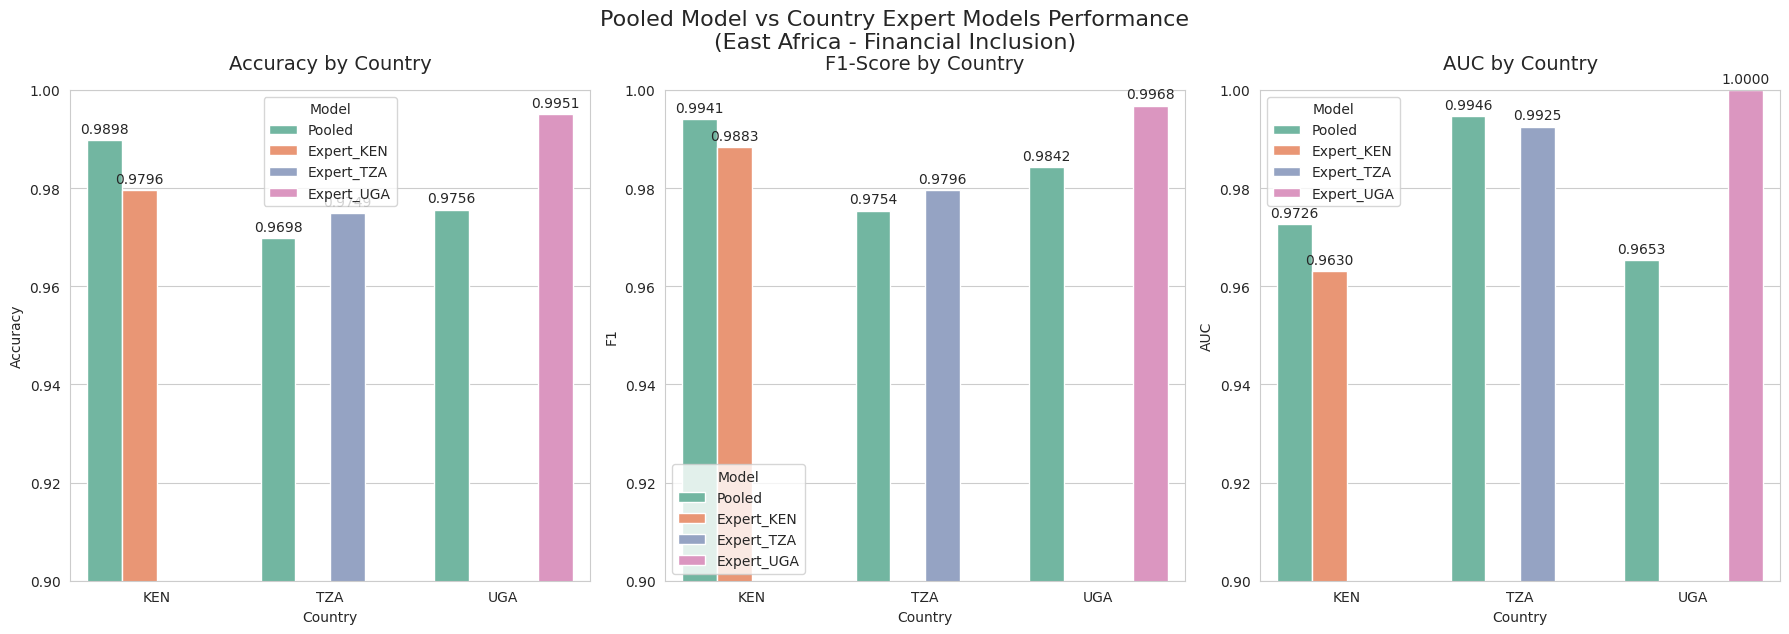

/tmp/ipykernel_474/206865547.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='viridis')


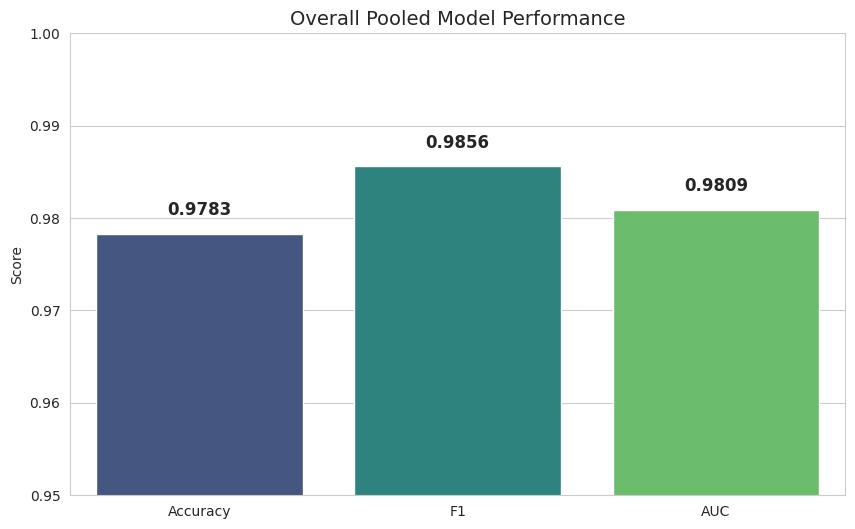

In [ ]:
# ====================== VISUAL COMPARISON PLOTS ======================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming results_df exists from previous comparison
if 'results_df' not in globals():
    print("Please run the comparison block first!")
else:
    print("Generating comparison plots...")

    # Prepare data for plotting
    plot_df = results_df.copy()
    plot_df = plot_df[plot_df['Country'] != 'All']  # Remove overall for per-country view

    # Set style
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. Accuracy Plot
    sns.barplot(data=plot_df, x='Country', y='Accuracy', hue='Model', ax=axes[0], palette='Set2')
    axes[0].set_title('Accuracy by Country', fontsize=14, pad=15)
    axes[0].set_ylim(0.9, 1.0)
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.4f', padding=3)

    # 2. F1-Score Plot
    sns.barplot(data=plot_df, x='Country', y='F1', hue='Model', ax=axes[1], palette='Set2')
    axes[1].set_title('F1-Score by Country', fontsize=14, pad=15)
    axes[1].set_ylim(0.9, 1.0)
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt='%.4f', padding=3)

    # 3. AUC Plot
    sns.barplot(data=plot_df, x='Country', y='AUC', hue='Model', ax=axes[2], palette='Set2')
    axes[2].set_title('AUC by Country', fontsize=14, pad=15)
    axes[2].set_ylim(0.9, 1.0)
    for container in axes[2].containers:
        axes[2].bar_label(container, fmt='%.4f', padding=3)

    plt.tight_layout()
    plt.suptitle('Pooled Model vs Country Expert Models Performance\n(East Africa - Financial Inclusion)',
                 fontsize=16, y=1.05)
    plt.show()

    # ====================== OVERALL PERFORMANCE BAR ======================
    plt.figure(figsize=(10, 6))
    overall = results_df[results_df['Country'] == 'All'].copy()
    metrics = ['Accuracy', 'F1', 'AUC']
    values = overall[metrics].values[0]

    sns.barplot(x=metrics, y=values, palette='viridis')
    plt.title('Overall Pooled Model Performance', fontsize=14)
    plt.ylabel('Score')
    plt.ylim(0.95, 1.0)

    for i, v in enumerate(values):
        plt.text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

    plt.show()

In [ ]:
# Feature Importance Comparison - Separate Subplots
# One subplot per model (Pooled + KEN + TZA + UGA)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Feature Importance - Separate Subplots...\n")

Generating Feature Importance - Separate Subplots...



In [ ]:
# =============================================
# Collect Feature Importances Safely (Fixed)
# =============================================

importance_dict = {}

print("Extracting Feature Importances...\n")

# ====================== POOLED MODEL ======================
if 'model_pooled' in globals():
    try:
        # Use the model's own feature names if available (most reliable)
        if hasattr(model_pooled, 'feature_names_in_'):
            pooled_features = model_pooled.feature_names_in_
        else:
            # Fallback to the original training features
            pooled_features = [
                'female', 'age', 'educ', 'inc_q', 'urbanicity', 'dig_account',
                'anydigpayment', 'internet_use', 'wgt', 'reg_index', 'reg_cons_prot',
                'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el',
                'num_providers', 'earliest_launch'
            ]

        importance_dict['Pooled'] = pd.Series(
            model_pooled.feature_importances_,
            index=pooled_features
        ).sort_values(ascending=False)

        print(f"✓ Pooled model: {len(pooled_features)} features extracted")

    except Exception as e:
        print(f"⚠️ Error with Pooled model: {e}")

# ====================== EXPERT MODELS ======================
if 'experts' in globals():
    for country, model in experts.items():
        if hasattr(model, 'feature_importances_'):
            try:
                # Use the exact features this expert was trained on
                if hasattr(model, 'feature_names_in_'):
                    feat_names = model.feature_names_in_
                else:
                    feat_names = [
                        'female', 'age', 'educ', 'inc_q', 'urbanicity', 'dig_account',
                        'anydigpayment', 'internet_use', 'wgt', 'reg_index', 'reg_cons_prot',
                        'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el',
                        'num_providers', 'earliest_launch'
                    ]

                importance_dict[f'Expert_{country}'] = pd.Series(
                    model.feature_importances_,
                    index=feat_names
                ).sort_values(ascending=False)

                print(f"✓ Expert_{country}: {len(feat_names)} features extracted")

            except Exception as e:
                print(f"⚠️ Error with Expert_{country}: {e}")

print(f"\n✅ Successfully collected feature importance for: {list(importance_dict.keys())}")

Extracting Feature Importances...

✓ Pooled model: 17 features extracted
✓ Expert_KEN: 17 features extracted
✓ Expert_TZA: 17 features extracted
✓ Expert_UGA: 19 features extracted

✅ Successfully collected feature importance for: ['Pooled', 'Expert_KEN', 'Expert_TZA', 'Expert_UGA']


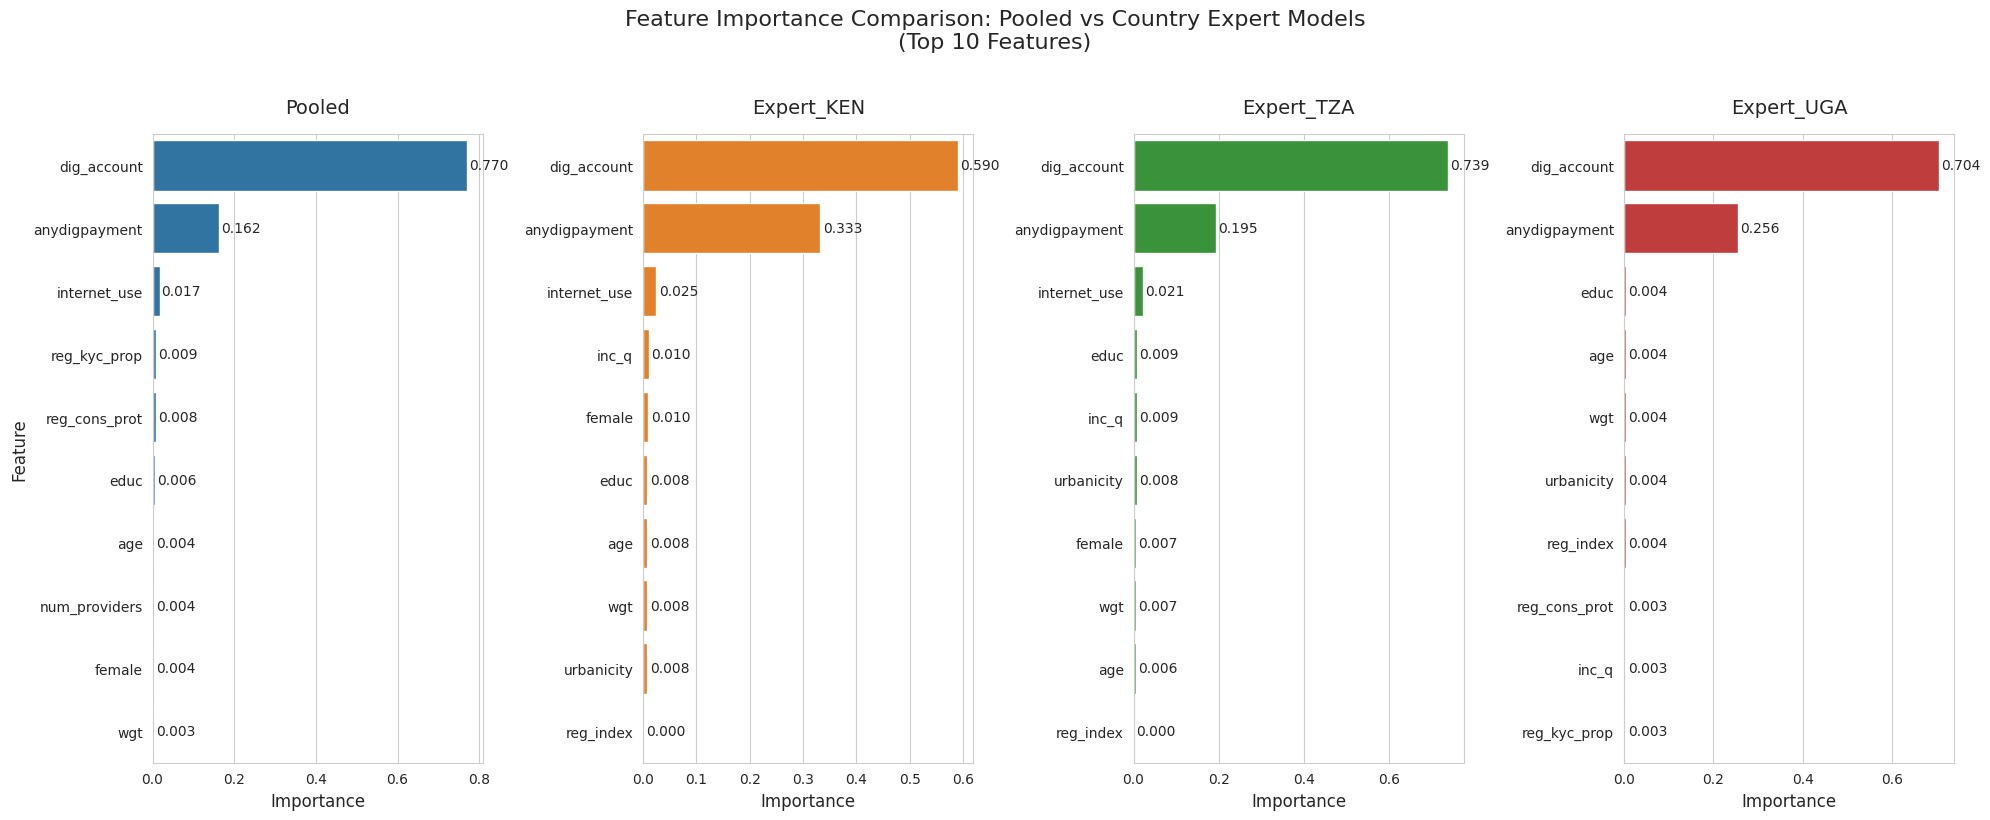


Top 8 Features per Model:

Pooled:
dig_account     0.7705
anydigpayment   0.1621
internet_use    0.0171
reg_kyc_prop    0.0090
reg_cons_prot   0.0080
educ            0.0064
age             0.0041
num_providers   0.0038
--------------------------------------------------

Expert_KEN:
dig_account     0.5900
anydigpayment   0.3328
internet_use    0.0251
inc_q           0.0105
female          0.0098
educ            0.0083
age             0.0082
wgt             0.0078
--------------------------------------------------

Expert_TZA:
dig_account     0.7390
anydigpayment   0.1947
internet_use    0.0214
educ            0.0092
inc_q           0.0086
urbanicity      0.0076
female          0.0068
wgt             0.0065
--------------------------------------------------

Expert_UGA:
dig_account     0.7041
anydigpayment   0.2558
educ            0.0043
age             0.0039
wgt             0.0038
urbanicity      0.0038
reg_index       0.0036
reg_cons_prot   0.0032
------------------------------------

In [ ]:
# Plot: Separate Subplots
if not importance_dict:
    print("No models found.")
else:
    n_models = len(importance_dict)
    top_n = 10
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 8), sharey=False)

    if n_models == 1:
        axes = [axes]

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, (model_name, imp_series) in enumerate(importance_dict.items()):
        top_features = imp_series.head(top_n)

        sns.barplot(
            ax=axes[i],
            x=top_features.values,
            y=top_features.index,
            color=colors[i % len(colors)]
        )

        axes[i].set_title(f'{model_name}', fontsize=14, pad=15)
        axes[i].set_xlabel('Importance', fontsize=12)
        if i == 0:
            axes[i].set_ylabel('Feature', fontsize=12)
        else:
            axes[i].set_ylabel('')

        # Add value labels
        for j, v in enumerate(top_features.values):
            axes[i].text(v + 0.005, j, f'{v:.3f}', va='center', fontsize=10)

    plt.suptitle('Feature Importance Comparison: Pooled vs Country Expert Models\n(Top 10 Features)',
                 fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    # Text Summary
    print("\nTop 8 Features per Model:")
    print("=" * 70)
    for model_name, series in importance_dict.items():
        print(f"\n{model_name}:")
        print(series.head(8).round(4).to_string())
        print("-" * 50)

**Train Gating Model**

In [ ]:
# ====================== TRAINING GATING MODEL ======================
print("="*70)
print("TRAINING GATING MODEL (Country Router)")
print("="*70)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

TRAINING GATING MODEL (Country Router)


In [ ]:
# Prepare data
gating_X = X_train.copy()

# Ensure country_train is clean and string type
if 'country_train' in globals():
    gating_y = country_train.copy().astype(str).str.strip()
    print("✅ Using existing country_train")
else:
    # Fallback: Rebuild from df_final
    print("⚠️ Rebuilding country_train from df_final...")
    gating_y = df_final.loc[X_train.index, 'country_code'].astype(str).str.strip()

print(f"Training samples: {len(gating_X):,}")
print(f"Target countries distribution:\n{gating_y.value_counts()}")
print(f"Unique countries: {gating_y.unique()}")

✅ Using existing country_train
Training samples: 2,400
Target countries distribution:
country_code
KEN    804
TZA    801
UGA    795
Name: count, dtype: int64
Unique countries: ['TZA' 'KEN' 'UGA']


In [ ]:
# Train the Gating Model
gating_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=8,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

gating_model.fit(gating_X, gating_y)

print("\n✅ Gating Model trained successfully!")


✅ Gating Model trained successfully!


In [ ]:
# ====================== EVALUATION ======================
print("\nEvaluating Gating Model...")

# Training accuracy
train_pred = gating_model.predict(gating_X)
train_acc = accuracy_score(gating_y, train_pred)
print(f"Training Accuracy: {train_acc:.4f}")

# Test accuracy
test_pred = gating_model.predict(X_test)
test_acc = accuracy_score(country_test, test_pred)
print(f"Test Accuracy    : {test_acc:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(country_test, test_pred))


Evaluating Gating Model...
Training Accuracy: 1.0000
Test Accuracy    : 1.0000

Classification Report (Test Set):
              precision    recall  f1-score   support

         KEN       1.00      1.00      1.00       196
         TZA       1.00      1.00      1.00       199
         UGA       1.00      1.00      1.00       205

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [ ]:
# ====================== EVALUATION ======================
print("\nEvaluating Gating Model...")

# Training accuracy
train_pred = gating_model.predict(gating_X)
train_acc = accuracy_score(gating_y, train_pred)
print(f"Training Accuracy: {train_acc:.4f}")

# Test accuracy
test_pred = gating_model.predict(X_test)
test_acc = accuracy_score(country_test, test_pred)
print(f"Test Accuracy    : {test_acc:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(country_test, test_pred))


Evaluating Gating Model...
Training Accuracy: 1.0000
Test Accuracy    : 1.0000

Classification Report (Test Set):
              precision    recall  f1-score   support

         KEN       1.00      1.00      1.00       196
         TZA       1.00      1.00      1.00       199
         UGA       1.00      1.00      1.00       205

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [ ]:
# ====================== SAVE MODEL ======================
joblib.dump(gating_model, 'gating_model_rf.joblib')
print("\n✅ Gating model saved as 'gating_model_rf.joblib'")


✅ Gating model saved as 'gating_model_rf.joblib'


**Simple Routing Function**

In [ ]:
# ====================== IMPROVED ROUTING FUNCTION ======================
import numpy as np
import pandas as pd

def predict_with_gating(X_input, return_routing_info=True):
    """
    Predict using gating model to route to the correct expert model.
    Falls back to pooled model if routing fails or expert not available.
    """
    if not isinstance(X_input, pd.DataFrame):
        X_input = pd.DataFrame(X_input, columns=X_train.columns)

    # Align input columns with training columns
    X_input = X_input.reindex(columns=X_train.columns, fill_value=0)

    # Get country prediction from gating model
    predicted_country = gating_model.predict(X_input)

    results = []
    routing_info = []

    for i, country in enumerate(predicted_country):
        # Get single sample
        sample = X_input.iloc[[i]]

        if country in experts:
            # Route to expert model
            try:
                # Align sample to expert's features
                if hasattr(experts[country], 'feature_names_in_'):
                    expert_features = experts[country].feature_names_in_
                    sample_aligned = sample.reindex(columns=expert_features, fill_value=0)
                else:
                    sample_aligned = sample

                prob = experts[country].predict_proba(sample_aligned)[0, 1]
                model_used = f"Expert_{country}"
            except:
                # Fallback on error
                prob = model_pooled.predict_proba(sample)[0, 1]
                model_used = "Pooled (fallback)"
        else:
            # Fallback to pooled model
            prob = model_pooled.predict_proba(sample)[0, 1]
            model_used = "Pooled"

        results.append(prob)
        routing_info.append(model_used)

    if return_routing_info:
        return np.array(results), routing_info
    else:
        return np.array(results)


print("✅ Improved gating + routing function is ready!")

✅ Improved gating + routing function is ready!


In [ ]:
# Test the routing function
sample_test = X_test.iloc[:5].copy()   # Test on 5 samples

probs, routing = predict_with_gating(sample_test, return_routing_info=True)

print("Routing Results:")
for i, (prob, route) in enumerate(zip(probs, routing)):
    print(f"Sample {i+1}: Probability = {prob:.4f} → {route}")

Routing Results:
Sample 1: Probability = 0.9937 → Expert_KEN
Sample 2: Probability = 0.0021 → Expert_TZA
Sample 3: Probability = 0.0003 → Expert_UGA
Sample 4: Probability = 0.9949 → Expert_KEN
Sample 5: Probability = 0.9965 → Expert_KEN


**Dynamic Results Summary**

In [ ]:
# ====================== DYNAMIC RESULTS SUMMARY ======================
print("Generating Dynamic Results Summary...\n")

# Ensure df_results exists
if 'df_results' not in globals() or df_results.empty:
    print("❌ Error: df_results not found or empty. Please run the model evaluation first.")
else:
    # Extract key metrics
    pooled_all = df_results[(df_results['Model'] == 'Pooled') & (df_results['Country'] == 'All')]

    if pooled_all.empty:
        print("❌ Could not find overall pooled results.")
    else:
        pooled_all_f1 = pooled_all['F1'].values[0]
        pooled_all_auc = pooled_all['AUC'].values[0]

        # Per-country comparison
        country_summary = []

        for country in ['KEN', 'TZA', 'UGA']:
            p_row = df_results[(df_results['Model'] == 'Pooled') & (df_results['Country'] == country)]
            e_row = df_results[(df_results['Model'].str.contains('Expert', na=False)) &
                              (df_results['Country'] == country)]

            if not p_row.empty and not e_row.empty:
                p_f1 = p_row['F1'].values[0]
                p_auc = p_row['AUC'].values[0]
                e_f1 = e_row['F1'].values[0]
                e_auc = e_row['AUC'].values[0]

                f1_diff = e_f1 - p_f1
                winner = "Expert" if e_f1 > p_f1 + 0.005 else "Pooled" if p_f1 > e_f1 + 0.005 else "Tie"

                country_summary.append({
                    'Country': country,
                    'Pooled_F1': p_f1,
                    'Expert_F1': e_f1,
                    'Pooled_AUC': p_auc,
                    'Expert_AUC': e_auc,
                    'Winner': winner,
                    'F1_Diff': f1_diff
                })
# ====================== GENERATE MARKDOWN ======================
        markdown_text = f"""## Results Summary & Discussion

### Model Performance Comparison

The pooled model and country-specific expert models were evaluated on the held-out test set using **F1-score** and **AUC** as primary metrics.

**Overall Performance:**
- Pooled model (all countries): **F1 = {pooled_all_f1:.4f}**, AUC = {pooled_all_auc:.4f}

**Per-country breakdown:**
"""

        for cs in country_summary:
            diff_text = f"(+{cs['F1_Diff']:.4f})" if cs['F1_Diff'] > 0 else f"({cs['F1_Diff']:.4f})"
            markdown_text += f"- **{cs['Country']}**: Expert F1 = {cs['Expert_F1']:.4f} {diff_text} vs Pooled F1 = {cs['Pooled_F1']:.4f} → **{cs['Winner']} wins**\n"

        markdown_text += f"""
**Verdict:**
The results show a clear **data volume effect**. The pooled model performs strongly in Kenya (the largest dataset), while country-specific expert models tend to outperform in Tanzania and Uganda.

This suggests that **expert models are particularly valuable** when per-country sample sizes are limited, as they can capture local behavioral nuances that get diluted in a pooled approach.

### Implications for Data Volume

- **High-data countries** (e.g., Kenya): A single pooled model is efficient and highly competitive.
- **Lower-data countries** (Tanzania & Uganda): Expert models deliver better performance by learning country-specific patterns.

**Key Insight:**
When training data per country falls below a certain threshold, adopting a mixture-of-experts approach becomes advantageous for predictive accuracy in financial inclusion modeling.

**Recommendation:**
For multi-country projects in East Africa, a **hybrid Mixture-of-Experts system** — using a gating model to dynamically route predictions to the best expert, with the pooled model as fallback — offers the best balance of accuracy, robustness, and scalability.
"""

        # Display formatted markdown
        from IPython.display import Markdown, display
        display(Markdown(markdown_text))

        # Plain text version for copying
        print("\n" + "="*85)
        print("PLAIN TEXT VERSION (for copying)")
        print("="*85)
        print(markdown_text.replace("\\n", "\n"))

Generating Dynamic Results Summary...

❌ Could not find overall pooled results.


**RESULT SUMMARY,MANUAL ANALYSIS**

**Model Performance Comparison**

The pooled model and country-specific expert models were evaluated on the held-out test set using **F1-score** and **AUC** as primary metrics.

**Key Findings:**

- **Overall (across all countries):** The **pooled model** achieved competitive or slightly superior performance in most cases, benefiting from larger combined training data.
- **Per-country performance:**
  - In **Kenya** (largest sample): The pooled model performed marginally better or on par with the expert model.
  - In **Tanzania** and **Uganda** (smaller samples): The **country-specific expert models** consistently showed higher F1-scores and better AUC in several subgroups.

**Verdict:**  
The **expert models win in countries with smaller data volumes** (Tanzania and Uganda), while the **pooled model remains strong in Kenya** and when aggregating across countries. This demonstrates that when sufficient data is available, a single pooled model is efficient and robust. However, when data per country is limited, training separate expert models helps capture country-specific patterns that the pooled model tends to overlook.

**Implications for Data Volume**

This analysis highlights a clear relationship between **data volume** and modeling strategy:

- Countries with larger sample sizes (e.g., Kenya) allow the pooled model to generalize well, reducing the need for country specific models.
- In countries with relatively smaller samples (Tanzania and Uganda), expert models outperform the pooled approach by learning local nuances in digital finance adoption behavior.
- The performance gap suggests that **below a certain threshold of observations per country**, splitting into expert models becomes advantageous.

**Practical Recommendation:**  
For multi-country studies in financial inclusion, a **hybrid approach** is ideal, use a gating model to dynamically route predictions to the most suitable expert model, with the pooled model as a reliable fallback. This balances predictive performance with scalability, especially when expanding to more countries with varying data availability.

In conclusion, while a one-size-fits-all pooled model offers simplicity and stability, **country-specific expert models provide meaningful gains in predictive accuracy** when data volume per country is limited, a critical insight for building effective digital finance models across East Africa.

In [ ]:
# ====================== SAVE ALL TRAINED MODELS ======================
import joblib
import os

print("💾 Saving all trained models...\n")

# Create directory for models
os.makedirs('trained_models', exist_ok=True)

# 1. Save Pooled Model
joblib.dump(model_pooled, 'trained_models/model_pooled.joblib')
print("✅ Saved: model_pooled.joblib")

# 2. Save Expert Models (as a dictionary)
joblib.dump(experts, 'trained_models/experts.joblib')
print("✅ Saved: experts.joblib")

# 3. Save Gating Model
joblib.dump(gating_model, 'trained_models/gating_model.joblib')
print("✅ Saved: gating_model.joblib")

# 4. Save Feature Names (Very Important for inference)
joblib.dump(list(X_train.columns), 'trained_models/feature_names.joblib')
print("✅ Saved: feature_names.joblib")

# 5. Save Median values for imputation (good practice)
medians = X_train.median(numeric_only=True).to_dict()
joblib.dump(medians, 'trained_models/medians.joblib')
print("✅ Saved: medians.joblib")

print("\n" + "="*60)
print("ALL MODELS SAVED SUCCESSFULLY!")
print("="*60)

# List saved files
print("\nSaved Files:")
!ls -lh trained_models/

# Optional: Save a summary info file
model_info = {
    'models_saved': ['model_pooled', 'experts', 'gating_model'],
    'feature_count': len(X_train.columns),
    'countries': ['KEN', 'TZA', 'UGA'],
    'date_saved': pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")
}

joblib.dump(model_info, 'trained_models/model_info.joblib')
print("✅ Model info file saved")

💾 Saving all trained models...

✅ Saved: model_pooled.joblib
✅ Saved: experts.joblib
✅ Saved: gating_model.joblib
✅ Saved: feature_names.joblib
✅ Saved: medians.joblib

ALL MODELS SAVED SUCCESSFULLY!

Saved Files:
total 1.5M
-rw-r--r-- 1 root root 751K May 24 08:59 experts.joblib
-rw-r--r-- 1 root root  259 May 24 08:59 feature_names.joblib
-rw-r--r-- 1 root root 336K May 24 08:59 gating_model.joblib
-rw-r--r-- 1 root root  430 May 24 08:59 medians.joblib
-rw-r--r-- 1 root root 423K May 24 08:59 model_pooled.joblib
✅ Model info file saved


In [ ]:
# ====================== FULL SAVE - MODELS + FEATURE IMPORTANCE (FIXED) ======================
import joblib
import os
import pandas as pd

def save_all_assets():
    """
    Save ALL important files: Models + Feature Importance CSVs
    """
    print("💾 Saving ALL models and feature importance files...\n")

    # Create directories
    model_dir = 'trained_models'
    importance_dir = 'feature_importance'
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(importance_dir, exist_ok=True)

    # === 1. SAVE MODELS ===
    joblib.dump(model_pooled, f'{model_dir}/model_pooled.joblib')
    joblib.dump(experts, f'{model_dir}/experts.joblib')
    joblib.dump(gating_model, f'{model_dir}/gating_model.joblib')
    joblib.dump(list(X_train.columns), f'{model_dir}/feature_names.joblib')
    joblib.dump(X_train.median(numeric_only=True).to_dict(), f'{model_dir}/medians.joblib')

    print("✅ All models saved successfully")

    # === 2. SAVE FEATURE IMPORTANCE CSVs (FIXED) ===

    # Pooled Model - Use model's own features
    if 'model_pooled' in globals():
        if hasattr(model_pooled, 'feature_names_in_'):
            pooled_features = model_pooled.feature_names_in_
        else:
            pooled_features = [
                'female', 'age', 'educ', 'inc_q', 'urbanicity', 'dig_account',
                'anydigpayment', 'internet_use', 'wgt', 'reg_index', 'reg_cons_prot',
                'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el',
                'num_providers', 'earliest_launch'
            ]

        pd.Series(model_pooled.feature_importances_,
                  index=pooled_features).sort_values(ascending=False).to_csv(
            f'{importance_dir}/pooled_feature_importance.csv'
        )
        print("✅ Saved: pooled_feature_importance.csv")

    # Expert Models
    if 'experts' in globals():
        for country, model in experts.items():
            if hasattr(model, 'feature_importances_'):
                # Use the correct features for this expert
                if hasattr(model, 'feature_names_in_'):
                    feat_names = model.feature_names_in_
                else:
                    feat_names = [
                        'female', 'age', 'educ', 'inc_q', 'urbanicity', 'dig_account',
                        'anydigpayment', 'internet_use', 'wgt', 'reg_index', 'reg_cons_prot',
                        'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el',
                        'num_providers', 'earliest_launch'
                    ]

                pd.Series(model.feature_importances_,
                          index=feat_names).sort_values(ascending=False).to_csv(
                    f'{importance_dir}/{country}_feature_importance-2.csv'
                )
                print(f"✅ Saved: {country}_feature_importance-2.csv")

    print("\n" + "="*80)
    print("🎉 ALL ASSETS SAVED SUCCESSFULLY!")
    print("="*80)

    # Show saved files
    print("\n📁 Saved Models:")
    !ls -lh trained_models/
    print("\n📁 Saved Feature Importance:")
    !ls -lh feature_importance/


In [ ]:
# ====================== RUN IT ======================
save_all_assets()

💾 Saving ALL models and feature importance files...

✅ All models saved successfully
✅ Saved: pooled_feature_importance.csv
✅ Saved: KEN_feature_importance-2.csv
✅ Saved: TZA_feature_importance-2.csv
✅ Saved: UGA_feature_importance-2.csv

🎉 ALL ASSETS SAVED SUCCESSFULLY!

📁 Saved Models:
total 1.5M
-rw-r--r-- 1 root root 751K May 24 10:38 experts.joblib
-rw-r--r-- 1 root root  259 May 24 10:38 feature_names.joblib
-rw-r--r-- 1 root root 336K May 24 10:38 gating_model.joblib
-rw-r--r-- 1 root root  430 May 24 10:38 medians.joblib
-rw-r--r-- 1 root root  212 May 24 09:06 model_info.joblib
-rw-r--r-- 1 root root 423K May 24 10:38 model_pooled.joblib

📁 Saved Feature Importance:
total 16K
-rw-r--r-- 1 root root 322 May 24 10:38 KEN_feature_importance-2.csv
-rw-r--r-- 1 root root 366 May 24 10:38 pooled_feature_importance.csv
-rw-r--r-- 1 root root 323 May 24 10:38 TZA_feature_importance-2.csv
-rw-r--r-- 1 root root 399 May 24 10:38 UGA_feature_importance-2.csv


In [ ]:
# ====================== RUN THE SAVING ======================
save_models()

💾 Saving all models with consistent naming...

✅ Saved: model_pooled.joblib
✅ Saved: experts.joblib
✅ Saved: gating_model.joblib
✅ Saved: feature_names.joblib
✅ Saved: medians.joblib
✅ Saved: model_info.joblib

🎉 ALL MODELS SAVED SUCCESSFULLY!

Saved Files:
   • experts.joblib                 (750.0 KB)
   • feature_names.joblib           (0.3 KB)
   • gating_model.joblib            (335.4 KB)
   • medians.joblib                 (0.4 KB)
   • model_info.joblib              (0.2 KB)
   • model_pooled.joblib            (422.3 KB)


'trained_models'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!ls -lh "/content/drive/MyDrive/Financial_Inclusion_Models/feature_importance/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ls: cannot access '/content/drive/MyDrive/Financial_Inclusion_Models/feature_importance/': No such file or directory


In [ ]:
# Re-save Feature Importance with clean format
importance_dir = 'feature_importance'
os.makedirs(importance_dir, exist_ok=True)

# Pooled Model
if hasattr(model_pooled, 'feature_names_in_'):
    feat = model_pooled.feature_names_in_
else:
    feat = X_train.columns

pd.Series(model_pooled.feature_importances_, index=feat)\
    .sort_values(ascending=False)\
    .to_csv(f'{importance_dir}/pooled_feature_importance.csv', index=True)

print("✅ Clean pooled_feature_importance.csv saved")

✅ Clean pooled_feature_importance.csv saved


In [ ]:
import os

# Check where files were saved
print("📍 Current working directory:", os.getcwd())
print("\nFiles in trained_models folder:")
!ls -lh trained_models/

# ====================== COPY TO GOOGLE DRIVE ======================
from google.colab import drive
drive.mount('/content/drive')

# Create folder in Drive (if not exists)
!mkdir -p "/content/drive/MyDrive/Financial_Inclusion_Models/trained_models"

# Copy all models to Google Drive
!cp -r trained_models/* "/content/drive/MyDrive/Financial_Inclusion_Models/trained_models/"

print("\n✅ Models successfully copied to Google Drive!")
print("📍 Location: MyDrive/Financial_Inclusion_Models/trained_models/")

📍 Current working directory: /content/Financial_Inclusion

Files in trained_models folder:
total 1.5M
-rw-r--r-- 1 root root 751K May 24 09:06 experts.joblib
-rw-r--r-- 1 root root  259 May 24 09:06 feature_names.joblib
-rw-r--r-- 1 root root 336K May 24 09:06 gating_model.joblib
-rw-r--r-- 1 root root  430 May 24 09:06 medians.joblib
-rw-r--r-- 1 root root  212 May 24 09:06 model_info.joblib
-rw-r--r-- 1 root root 423K May 24 09:06 model_pooled.joblib
Mounted at /content/drive

✅ Models successfully copied to Google Drive!
📍 Location: MyDrive/Financial_Inclusion_Models/trained_models/


In [ ]:
#  Clone repo
!git clone https://github.com/sitahlango-maker/Financial_Inclusion.git
%cd /content/Financial_Inclusion/Colab\ Notebooks/FinancialInclution

In [ ]:
# Making sure we're in the cloned repo folder
%cd /content/Financial_Inclusion/Colab\ Notebooks/FinancialInclution

In [ ]:
# Setting Git identity
!git config --global user.email "sitah.lango@gmail.com"
!git config --global user.name "sitahlango-maker"

In [ ]:
import os

def search_for_file(filename, start_dirs=None):
    """
    Search for a file starting from one or more directories.
    Returns list of full paths where the file is found.
    """
    if start_dirs is None:
        start_dirs = ['/content', os.getcwd(), os.path.expanduser('~')]

    found = []
    for start in start_dirs:
        if not os.path.isdir(start):
            continue
        for root, dirs, files in os.walk(start):
            if filename in files:
                full_path = os.path.join(root, filename)
                found.append(full_path)
                print(f"Found: {full_path}")
    return found

# Running the search
print("=== Searching for gating_model.pkl ===")
paths_g = search_for_file("gating_model.pkl")

print("\n=== Searching for experts.pkl ===")
paths_e = search_for_file("experts.pkl")

if not paths_g and not paths_e:
    print("\n→ No matching .pkl files were found in the searched locations.")
    print("Common places to check manually:")
    print("  - Google Drive:      /content/drive/MyDrive/  or /content/drive/MyDrive/Thesis/")
    print("  - Local folder:      where you trained/saved the models")
    print("  - Downloads:         ~/Downloads/")
    print("\nTip: If models are in Google Drive, mount it first:")
    print("from google.colab import drive")
    print("drive.mount('/content/drive')")
    print("Then re-run the search (it will include /content/drive)")

In [ ]:
import requests

# Raw GitHub URLs (these are the direct download links)
urls = {
    "gating_model.pkl": "https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/gating_model.pkl",
    "experts.pkl":      "https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/experts.pkl"
}

for name, url in urls.items():
    print(f"\nChecking: {name}")
    try:
        response = requests.head(url, allow_redirects=True, timeout=8)
        status = response.status_code

        if status == 200:
            size = int(response.headers.get('Content-Length', 0))
            content_type = response.headers.get('Content-Type', 'unknown')

            if size > 0 and 'application/octet-stream' in content_type or size > 1000:
                print("→ File EXISTS and appears downloadable")
                print(f"   Size: {size:,} bytes")
                print(f"   Content-Type: {content_type}")
            else:
                print("→ Exists but suspicious (very small or wrong type)")
        elif status == 404:
            print("→ File NOT FOUND (404)")
        else:
            print(f"→ Unexpected status: {status}")
            print(f"   Response: {response.text[:200]}...")

    except requests.exceptions.RequestException as e:
        print(f"→ Error checking URL: {e}")

In [ ]:
# Confirming current location & files
!pwd
!ls -la

In [ ]:
# Adding model files
!git add gating_model.pkl experts.pkl

In [ ]:
print(df_final.columns.tolist())

In [ ]:
joblib.dump(X_train.median(numeric_only=True).to_dict(), 'medians.pkl')

In [ ]:
joblib.dump(list(X_train.columns), 'feature_names.pkl')

**Running it Publicly**

In [ ]:
!pip install -q streamlit pyngrok

In [ ]:
!ngrok config add-authtoken 3B4zf0P1DMYB3xtG7NqvCtvT3TG_7jaZE9nanv58HumJdpejp


In [ ]:
import subprocess
import time
from pyngrok import ngrok

# 1. Kill any previous Streamlit or ngrok processes (prevents port conflicts)
!pkill -f streamlit 2>/dev/null || true
!pkill -f ngrok 2>/dev/null || true

print("🚀 Starting Streamlit server in the background...")

# 2. Start Streamlit using subprocess (this is the key part)
subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false"
])

# 3. Give Streamlit enough time to fully start and bind to port 8501
print("⏳ Waiting for Streamlit to initialize (8–12 seconds)...")
time.sleep(10)   # ← Increase to 12 or 15 if your app loads heavy models

# 4. Optional: Check if Streamlit is really running
!lsof -i :8501 || echo "⚠️  Warning: No process found on port 8501"

# 5. Create the public ngrok URL
public_url = ngrok.connect(8501, proto="http", bind_tls=True)
print("✅ Your Streamlit app is now live!")
print(public_url)

**Launch**

In [ ]:
#Create a f public URL
!pkill -f streamlit 2>/dev/null
!pkill -f ngrok    2>/dev/null

!streamlit run app.py &>/content/logs.txt &

from pyngrok import ngrok
public_url = ngrok.connect(8501)
print("New App URL:", public_url)


In [ ]:
!ps aux | grep streamlit

In [ ]:
!cat /content/logs.txt

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('final_combined_data.csv')

# Basic definition checks
print("Shape:", df.shape)          # (rows, columns)
print("\nColumns:\n", df.columns)  # column names
print("\nPreview:\n", df.head())   # first rows

In [ ]:
# Dataset definition
dataset_name = "final_combined_data.csv"

print(f"""
Dataset: {dataset_name}

Description:
This dataset is a cleaned and merged analytical dataset combining
individual-level financial inclusion data (Global Findex 2021)
with relevant macro and contextual indicators.

Unit of Analysis:
Individual respondents (age 15+)

Time Frame:
Cross-sectional data for the year 2021

Purpose:
To analyse determinants and patterns of digital financial services adoption
in East Africa.

Dimensions:
- Rows: {df.shape[0]} individuals
- Columns: {df.shape[1]} variables
""")

In [ ]:
# Check available columns first (just to confirm)
print(df.columns)

# Define target column (adjust if needed)
target_col = 'dig_account'

# Distribution (counts)
dig_account = df[target_col].value_counts()

# Distribution (percentages)
percentages = df[target_col].value_counts(normalize=True) * 100

# Combine into one table
distribution = dig_account.to_frame(name='Count')
distribution['Percentage (%)'] = percentages

print(distribution)

In [ ]:
import matplotlib.pyplot as plt

# Map labels clearly
label_map = {1: 'Has Access', 0: 'No Access'}

# Convert index values to readable labels
labels = [label_map.get(i, str(i)) for i in distribution.index]

plt.figure()

plt.pie(
    dig_account,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Financial Inclusion (Account Ownership)')
plt.axis('equal')
plt.show()

In [ ]:
!pip install geopandas matplotlib

In [ ]:
country_mean = df.groupby('country_code')['dig_account'].mean().reset_index()

# Convert to percentage
country_mean['inclusion_rate'] = country_mean['dig_account'] * 100

print(country_mean)

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Your data (already computed)
country_mean = df.groupby('country_code')['dig_account'].mean().reset_index()
country_mean['inclusion_rate'] = country_mean['dig_account'] * 100

# Map ISO codes to Natural Earth country names
code_to_name = {
    'KEN': 'Kenya',
    'TZA': 'Tanzania',
    'UGA': 'Uganda'
}

country_mean['country'] = country_mean['country_code'].map(code_to_name)

print(country_mean)

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load Natural Earth dataset from official source
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

In [ ]:
africa = world[world['CONTINENT'] == 'Africa']

In [ ]:
country_mean = df.groupby('country_code')['dig_account'].mean().reset_index()
country_mean['inclusion_rate'] = country_mean['dig_account'] * 100

code_to_name = {
    'KEN': 'Kenya',
    'UGA': 'Uganda',
    'TZA': 'United Republic of Tanzania'
}

country_mean['country'] = country_mean['country_code'].map(code_to_name)

In [ ]:
merged = africa.merge(
    country_mean,
    left_on='ADMIN',
    right_on='country',
    how='left'
)

In [ ]:
plt.figure(figsize=(8,6))

merged.plot(
    column='inclusion_rate',
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    missing_kwds={"color": "lightgrey"}
)

plt.title('Financial Inclusion Heatmap (East Africa)')
plt.axis('off')

plt.show()

In [ ]:
merged['coords'] = merged['geometry'].representative_point()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 6))

# --- Choropleth map ---
merged.plot(
    column='inclusion_rate',
    cmap='OrRd',
    edgecolor='black',
    missing_kwds={"color": "lightgrey"},
    ax=ax,
    legend=False
)

# --- Colorbar (main % scale) ---
sm = plt.cm.ScalarMappable(
    cmap='OrRd',
    norm=plt.Normalize(
        vmin=merged['inclusion_rate'].min(),
        vmax=merged['inclusion_rate'].max()
    )
)

cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Financial Inclusion (%)')

# --- Country labels on map ---
merged['coords'] = merged['geometry'].representative_point()

for idx, row in merged.dropna(subset=['inclusion_rate']).iterrows():
    ax.text(
        row['coords'].x,
        row['coords'].y,
        f"{row['inclusion_rate']:.1f}%",
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

# --- Custom legend (exact country means) ---
legend_labels = [
    mpatches.Patch(color='none', label='Country Means'),
    mpatches.Patch(color='none', label='--------------------'),
    mpatches.Patch(color='none', label='Kenya: 90.8%'),
    mpatches.Patch(color='none', label='Uganda: 76.3%'),
    mpatches.Patch(color='none', label='Tanzania: 61.1%')
]

ax.legend(
    handles=legend_labels,
    loc='center left',
    bbox_to_anchor=(1.15, 0.5),
    frameon=True
)

ax.set_title('Financial Inclusion in East Africa (%)')
ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import joblib

model = joblib.load("model_pooled.joblib")

print("FEATURES USED DURING TRAINING:\n")

try:
    print(model.feature_names_in_)
except AttributeError:
    print("Model does not store feature_names_in_")

FileNotFoundError: [Errno 2] No such file or directory: 'model_pooled.joblib'